<div style="text-align: center;">

## Empirical Bayes (Only) Regret Simulations 
#### Nora Sun (February 13, 2026)
</div>

<div style="text-align: center;">
Below, we show that in the case when the true means and taus are the same, the regret is indeed invariant across different means *when* the prior assumed by empirical Bayes magically matches the true mean and variance.
</div>

### Packages

In [7]:
import numpy as np
import math 
import matplotlib.pyplot as plt
import random

In [24]:
GLOBAL_SEED = 88888888
np.random.seed(GLOBAL_SEED)

### Environment

In [9]:
# number of participants
n = 50 

# number of arms/actions
arms = 2

# random number for fake data
rng = np.random.default_rng(0)

In [10]:
### Old Code (one mean/variance)

# population mean
mu_a = 0

# population variance
tau_a = 1

# true mean reward (using random data) theta[i,a] for participant i and action a
theta = rng.normal(loc=mu_a, scale=tau_a, size=(n, arms))

theta[:5]

# within-person variance
sigma_r = 1 

def get_reward(i, a):
    return rng.normal(loc=theta[i,a], scale=sigma_r)

get_reward(0, 1), get_reward(0, 1), get_reward(0, 1)

(0.3705779865835638, 0.8576081699945031, -0.29639945591659256)

In [18]:
def set_environment(n_new, arms_new, mu_new, tau_new, env_seed=0):
    global n, arms, mu_a, tau_a, rng, theta
    n = int(n_new)
    arms = int(arms_new)
    mu_a = float(mu_new)
    tau_a = float(tau_new)
    rng = np.random.default_rng(env_seed)
    theta = rng.normal(loc=mu_a, scale=tau_a, size=(n, arms))

In [11]:
# true mean reward (using random data) theta[i,a] for participant i and action a
def simulate_true_mean_reward(n_participants, mu_arm, tau_arm, seed=0):
    rng = np.random.default_rng(seed)

    # makes np array
    mu_arm = np.asarray(mu_arm)
    tau_arm = np.asarray(tau_arm)

    A = mu_arm.size
    
    theta = rng.normal(loc=mu_arm, scale=tau_arm, size=(n_participants, A))
    return theta

theta = simulate_true_mean_reward(n, mu_a, tau_a, seed=42)

#### Simulation specifics

In [16]:
# number of decision times
T = 200

# rate
epsilon = 0

# estimate of arm value
Q = np.zeros((n, arms))

# number of times arm tried
N = np.zeros((n, arms), dtype=int)

actions = np.zeros((n, T), dtype=int)
rewards = np.zeros((n, T))

### Empirical Bayes

In [35]:
def learning_empirical_bayes(times, participants, n_arms, mu0, tau0, seed=0):
    rng = np.random.default_rng(seed)
    sigma2 = float(sigma_r) ** 2

    # these are our priors 
    m = np.full((participants, n_arms), float(mu0))
    v = np.full((participants, n_arms), float(tau0) ** 2)

    N = np.zeros((participants, n_arms), dtype=int)
    actions = np.zeros((participants, times), dtype=int)
    rewards = np.zeros((participants, times), dtype=float)

    def normal_cdf(z):
        return 0.5 * (1.0 + math.erf(z / math.sqrt(2.0)))

    # the two functions below fit the hierarchical model based on learning algorithm's outputs 
    def profile_ll_and_mu(x, s2, tau2):
        w = 1.0 / (s2 + tau2)
        mu = np.sum(w * x) / np.sum(w)
        ll = -0.5 * np.sum(np.log(s2 + tau2) + (x - mu) ** 2 * w)
        return ll, mu

    def fit_mu_tau2(x, s2):
        x = np.asarray(x, dtype=float)
        s2 = np.asarray(s2, dtype=float)

        base = float(np.var(x)) + float(np.mean(s2))
        hi = max(1e-6, 10.0 * base)
        grid = np.logspace(-8, np.log10(hi), 120)

        best_tau2 = 0.0
        best_ll, best_mu = profile_ll_and_mu(x, s2, 0.0)

        for tau2 in grid:
            ll, mu = profile_ll_and_mu(x, s2, float(tau2))
            if ll > best_ll:
                best_ll, best_mu, best_tau2 = ll, mu, float(tau2)

        return best_mu, best_tau2

    # okay let's loop through all the decision times using the functions we defined above to do EB
    for t in range(times):
        # these are the *hyper*parameters aka population-level parameters
        mu_hat = np.zeros(n_arms, dtype=float)
        tau2_hat = np.zeros(n_arms, dtype=float)

        for a in range(n_arms):
            mu_hat[a], tau2_hat[a] = fit_mu_tau2(m[:, a], v[:, a])

        # these are the *person*-level parameters
        m_eb = np.zeros_like(m, dtype=float)
        v_eb = np.zeros_like(v, dtype=float)

        # let's compute the posteriors .....
        for a in range(n_arms):
            if tau2_hat[a] <= 0.0:
                m_eb[:, a] = mu_hat[a]
                v_eb[:, a] = 0.0
            else:
                lam = tau2_hat[a] / (tau2_hat[a] + v[:, a])
                m_eb[:, a] = lam * m[:, a] + (1.0 - lam) * mu_hat[a]
                v_eb[:, a] = 1.0 / (1.0 / v[:, a] + 1.0 / tau2_hat[a])

        # now using the posteriors we can determine distribution of difference between the two arms & based on that we select an action!
        for i in range(participants):
            if n_arms == 2:
                m_diff = m_eb[i, 1] - m_eb[i, 0]
                v_diff = v_eb[i, 1] + v_eb[i, 0]
                if v_diff <= 0.0:
                    a = 1 if m_diff > 0.0 else 0
                else:
                    p1 = normal_cdf(m_diff / math.sqrt(v_diff))
                    a = 1 if rng.random() < p1 else 0
            else:
                sample = rng.normal(loc=m_eb[i], scale=np.sqrt(np.maximum(v_eb[i], 0.0)))
                a = int(np.argmax(sample))

            # reward time! yay! let's see what reward we get based on the action...
            r = get_reward(i, a)

            actions[i, t] = a
            rewards[i, t] = r
            N[i, a] += 1

            # okay time to learn from the reward
            prec = 1.0 / v[i, a] + 1.0 / sigma2
            v_new = 1.0 / prec
            m_new = v_new * (m[i, a] / v[i, a] + r / sigma2)

            m[i, a] = m_new
            v[i, a] = v_new

    return m, v, N, actions, rewards

#### Cumulative Regret

Case where algorithm prior is magically true mean.

In [44]:
def cumulative_regret(theta, actions):
    n, T = actions.shape
    best = theta.max(axis=1, keepdims=True)
    chosen = theta[np.arange(n)[:, None], actions]
    inst = best - chosen
    return np.cumsum(inst.mean(axis=0))

def evaluate(seed=8888888, eps=None, mu0=0.0, tau0=1.0):
    if eps is None:
        eps = epsilon

    m_eb, v_eb, N_eb, actions_eb, rewards_eb = learning_empirical_bayes(
        T, n, arms, mu0=mu0, tau0=tau0, seed=seed
    )

    reg_eb = cumulative_regret(theta, actions_eb)

    return {
        "actions_eb": actions_eb,
        "regret_eb": reg_eb,
        "rewards_eb": rewards_eb,
        "m_eb": m_eb,
        "v_eb": v_eb,
        "N_eb": N_eb,
    }

#### Correct priors

In [49]:
def plot_true(ns, mus, taus, n_runs=10, env_seed=0, eps=None):
    if eps is None:
        eps = epsilon

    PASTEL = {"eb": "#8DE5A1"}

    n_rows = len(taus)
    n_cols = len(mus)

    for n_val in ns:
        fig, axs = plt.subplots(
            n_rows, n_cols,
            figsize=(3.2 * n_cols, 2.4 * n_rows),
            sharex=True, sharey=True
        )

        if n_rows == 1 and n_cols == 1:
            axs = np.array([[axs]])
        elif n_rows == 1:
            axs = np.array([axs])
        elif n_cols == 1:
            axs = np.array([[ax] for ax in axs])

        for i, tau_val in enumerate(taus):
            for j, mu_val in enumerate(mus):
                set_environment(n_val, arms, mu_val, tau_val, env_seed=env_seed)

                reg_eb_list = []
                for r in range(n_runs):
                    out = evaluate(seed=r, eps=eps, mu0=mu_val, tau0=tau_val)
                    reg_eb_list.append(out["regret_eb"])

                reg_eb = np.mean(reg_eb_list, axis=0)

                ax = axs[i, j]
                ax.plot(reg_eb, color=PASTEL["eb"], linewidth=1.4, label="EB")

                ax.set_title(f"μ={mu_val}, τ={tau_val}", fontsize=9)
                ax.tick_params(axis="both", labelsize=7)

                if i == n_rows - 1:
                    ax.set_xlabel("t", fontsize=8)
                if j == 0:
                    ax.set_ylabel("Avg cum. regret", fontsize=8)

        # legend (just EB)
        handles, labels = axs[0, 0].get_legend_handles_labels()
        fig.legend(handles, labels, loc="upper right", fontsize=8)

        fig.suptitle(f"n = {n_val}", fontsize=11)
        fig.tight_layout(rect=[0, 0, 0.95, 0.95])
        plt.show()

Below, we show that regret is invariant to translation of the mean. 

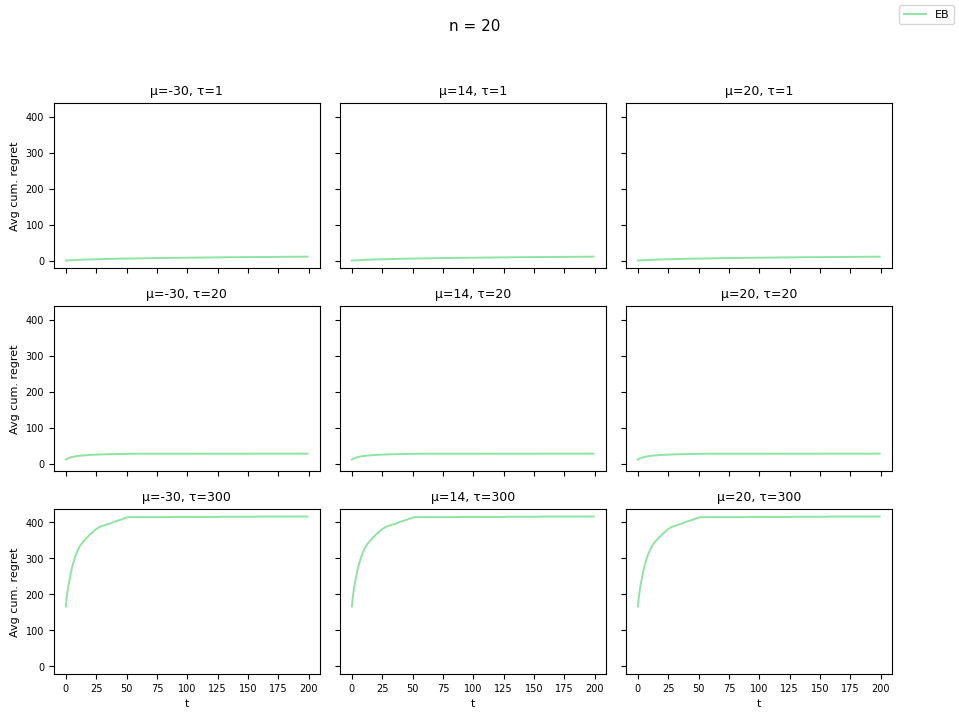

In [50]:
ns = [20]
mus = [-30, 14, 20]
taus = [1, 20, 300]

plot_true(ns, mus, taus)

# 10 runs

#### Incorrect priors (0,1)

In [53]:
def plot_mis(ns, mus, taus, n_runs=5, env_seed=0, eps=None):
    if eps is None:
        eps = epsilon

    PASTEL = {"eb": "#8DE5A1"}

    n_rows = len(taus)
    n_cols = len(mus)

    for n_val in ns:
        fig, axs = plt.subplots(
            n_rows, n_cols,
            figsize=(3.2 * n_cols, 2.4 * n_rows),
            sharex=True, sharey=True
        )

        if n_rows == 1 and n_cols == 1:
            axs = np.array([[axs]])
        elif n_rows == 1:
            axs = np.array([axs])
        elif n_cols == 1:
            axs = np.array([[ax] for ax in axs])

        for i, tau_val in enumerate(taus):
            for j, mu_val in enumerate(mus):
                set_environment(n_val, arms, mu_val, tau_val, env_seed=env_seed)

                reg_eb_list = []
                for r in range(n_runs):
                    out = evaluate(seed=r, eps=eps, mu0=0, tau0=1)
                    reg_eb_list.append(out["regret_eb"])

                reg_eb = np.mean(reg_eb_list, axis=0)

                ax = axs[i, j]
                ax.plot(reg_eb, color=PASTEL["eb"], linewidth=1.4, label="EB")

                ax.set_title(f"μ={mu_val}, τ={tau_val}", fontsize=9)
                ax.tick_params(axis="both", labelsize=7)

                if i == n_rows - 1:
                    ax.set_xlabel("t", fontsize=8)
                if j == 0:
                    ax.set_ylabel("Avg cum. regret", fontsize=8)

        # legend (just EB)
        handles, labels = axs[0, 0].get_legend_handles_labels()
        fig.legend(handles, labels, loc="upper right", fontsize=8)

        fig.suptitle(f"n = {n_val}", fontsize=11)
        fig.tight_layout(rect=[0, 0, 0.95, 0.95])
        plt.show()

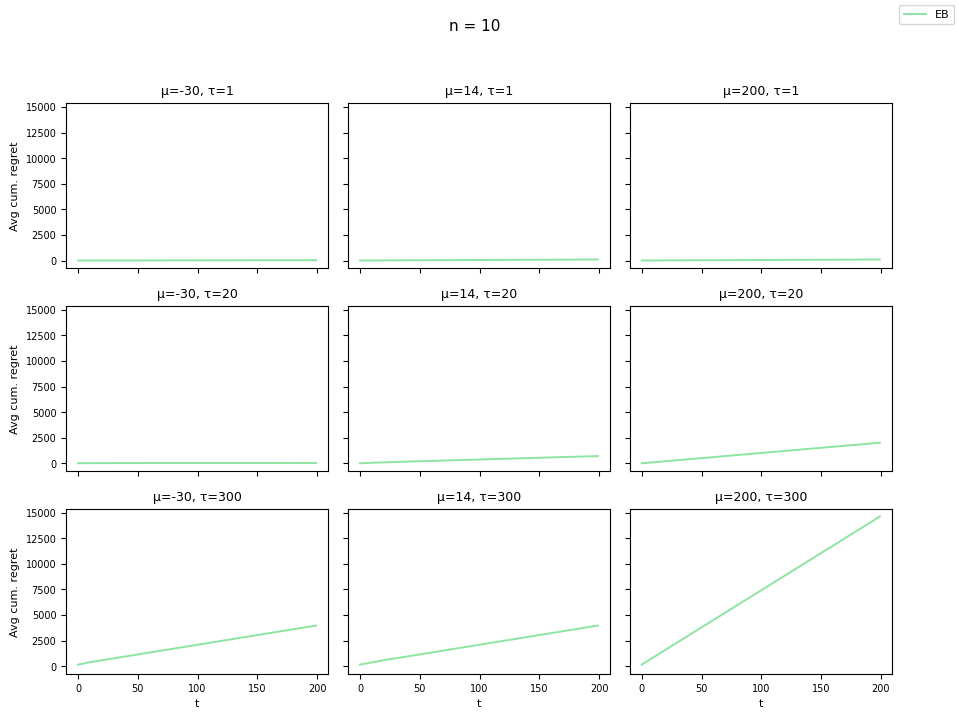

In [55]:
ns = [10]
mus = [-30, 14, 200]
taus = [1, 20, 300]

plot_mis(ns, mus, taus)

# 10 runs